In [2]:
import cv2
import numpy as np
import os
import sys
import shutil
from PIL import Image
from paddle.vision.transforms import functional as F
import re
from ast import literal_eval
from PIL import ImageDraw, ImageFont
import matplotlib.pyplot as plt

In [3]:
source_imgs_dir = 'C:\\Users\\hp\\Desktop\\imgs_all1\\'
source_label_dir = 'C:\\Users\\hp\\Desktop\\imgs_all1\\'
_source_name_lists = os.listdir(source_imgs_dir)

imgs_name = []
for _item in _source_name_lists:
    if _item.split('.')[-1] in ['jpg', 'png', 'bmp', 'jpeg']:
        imgs_name.append(_item)

# 读取文本文件
_path = os.path.join(source_label_dir, 'Label2.txt')
with open(_path, 'r', encoding='utf-8') as f:
    contents_label = f.readlines()
_path = os.path.join(source_label_dir, 'fileState2.txt')
with open(_path, 'r', encoding='utf-8') as f:
    contents_state = f.readlines()


In [4]:
# 把标签中的图片和其索引对应起来，方便后面使用
img_to_label_key = {}
for _i in range(0, len(contents_label)):
    img_to_label_key[(contents_label[_i].split('\t')[0]).split('/')[-1]] = _i

In [5]:
def smooth(factor, index, contents_label, img_to_label_key, imgs_name):
    
    one_label = contents_label[img_to_label_key[imgs_name[index]]]
    src_array_str = re.findall(r'points": (.+?), "difficult', one_label) # 找出点
    _reslist = [literal_eval(_it) for _it in src_array_str] # 点转为列表
    _reslistNumpy = np.array(_reslist)
    _reslistNumpy = _reslistNumpy.astype(np.float32)

    _center_M = np.array([[0.25, 0.25, 0.25, 0.25]], dtype=np.float32)
    _scale_M = np.array([[1.0,0.0],[0.0,1.0]], dtype=np.float32) * factor
    # _scale_M = np.array([[1.0,1.0]], dtype=np.float32) * factor
    _center = _center_M @ _reslistNumpy
    _reslistNumpy_origin = _reslistNumpy - _center
    _resExpand = _reslistNumpy_origin @ _scale_M
    # _resExpand = _reslistNumpy_origin @ _scale_M
    _resExpandDst = _resExpand + _center
    
    return _resExpandDst, src_array_str, one_label

In [7]:
# 标签平滑， 在数据增强后平滑

_label_file_name = "Label.txt"
seq_w = np.hstack((np.linspace(1.05,1.08, 10), np.linspace(1.08,1.12,70)))
seq_h = np.hstack((np.linspace(1.1,1.15, 10), np.linspace(1.15,1.2,70)))
with open(os.path.join(source_imgs_dir,_label_file_name),'wb') as f1:
    
    for i in range(0, len(imgs_name)):
        scale_factor = np.array([[np.random.choice(seq_w), 0], [0, np.random.choice(seq_h)]], dtype=np.float32)
        points_result, src_array_str, one_label = smooth(scale_factor, i, contents_label, img_to_label_key, imgs_name)
        
        points_result_int = points_result.astype(np.int32) # 转为int类型
        # 索引是一一对应的，数字数组转字符数组
        points_result_list = points_result_int.tolist()
        points_result_list_str = []
        for _it in points_result_list:
            points_result_list_str.append(str(_it))
        
        # 把原来的点转为模式 
        src_array_str_patten = []
        for _it in src_array_str:
            _new_patten = ''
            for i in range(0, len(_it)):
                if _it[i] == '[' or _it[i] == ']':
                    _new_patten = _new_patten + '\\'
                _new_patten = _new_patten + _it[i]
            src_array_str_patten.append(_new_patten)
            
        # 取代原来的点
        new_label = one_label
        for _src, _dst in zip (src_array_str_patten, points_result_list_str):
            new_label = re.sub(_src, _dst , new_label)

        f1.write(new_label.encode())


In [4]:
def draw_rotate(img, points):
    draw = ImageDraw.Draw(img)
    for rrect in points:
        for i in range(0, len(rrect)):
            draw.line((rrect[i][0], rrect[i][1], rrect[(i+1)%4][0], rrect[(i+1)%4][1]))

In [9]:
def check_smooth(index):
    print(imgs_name[index])
    one_label = contents_label[img_to_label_key[imgs_name[index]]]
    src_array_str = re.findall(r'points": (.+?), "difficult', one_label) # 找出点
    _reslist = [literal_eval(_it) for _it in src_array_str] # 点转为列表
    _reslistNumpy = np.array(_reslist)
    _reslistNumpy = _reslistNumpy.astype(np.float32)

    _center_M = np.array([[0.25, 0.25, 0.25, 0.25]], dtype=np.float32)
    _scale_M = np.array([[1.0,0.0],[0.0,1.0]], dtype=np.float32) * 1.1
    _center = _center_M @ _reslistNumpy
    _reslistNumpy_origin = _reslistNumpy - _center
    _resExpand = _reslistNumpy_origin @ _scale_M
    _resExpandDst = _resExpand + _center

    plt.figure(figsize=(18,24))
    for _i, _pl in enumerate([_reslist, _resExpandDst]):
        img = Image.open(os.path.join(source_imgs_dir, imgs_name[index]))
        draw_rotate(img, _pl)
        plt.subplot(1,2,_i+1)
        plt.imshow(img)

10_1.jpg


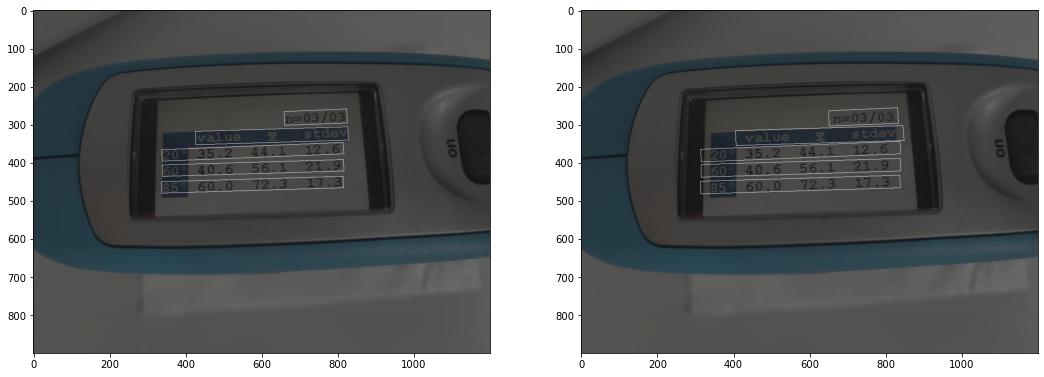

In [10]:
index = 3
check_smooth(index)